Notebook to calculate total cases, peak height, peak week, and $R_0$ for each model's predictions.

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as st
import mosqlient as mosq
from epiweeks import Week
from aux_func import get_data
from analysis import * 
import matplotlib.pyplot as plt 
import seaborn as sns 
from mosqlient.prediction_optimize import get_df_pars_ls

In [3]:
code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

state_to_code = {value: key for key, value in code_to_state.items()}

geo_dengue = [2931350,2933307,2302503,3119401,
              3549805,3541406,1200401,1200203,
              1716109,4113700,4103701,4104808,
              5201405,5102637,5215231]

geo_chik = [2211001,2931350,3143302,3119401,
            1721000,1716109,4104808,4219507,
            5103403,5102637] 

In [4]:
challenge = 'dengue_city'
col_region = 'adm_2'

In [5]:
df_dengue_state  = get_data(challenge)
df_dengue_state.date = pd.to_datetime(df_dengue_state.date)

In [6]:
df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_2,id,validation,wis,model
0,2022-10-09,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2931350,7890,1,19.57,3rd_imdc_isi_isi-dengue
1,2022-10-16,7.624455,8.057647,8.563331,9.403538,10.336016,11.416484,12.340992,12.851863,13.190387,2931350,7890,1,19.57,3rd_imdc_isi_isi-dengue
2,2022-10-23,0.002200,0.019268,0.094842,0.246298,0.516110,1.013062,1.639324,2.108751,2.516792,2931350,7890,1,19.57,3rd_imdc_isi_isi-dengue
3,2022-10-30,0.008068,0.008721,0.009537,0.011092,0.013063,0.015955,0.020393,0.024022,0.032237,2931350,7890,1,19.57,3rd_imdc_isi_isi-dengue
4,2022-11-06,0.206284,0.211000,0.216696,0.225576,0.237373,0.250423,0.263142,0.271593,0.286299,2931350,7890,1,19.57,3rd_imdc_isi_isi-dengue


In [7]:
df_preds.isnull().sum()

date          0
lower_95      0
lower_90      0
lower_80      0
lower_50      0
pred          0
upper_50      0
upper_80      0
upper_90      0
upper_95      0
adm_2         0
id            0
validation    0
wis           0
model         0
dtype: int64

In [10]:
df_dengue_state = df_dengue_state.merge(
        df_preds[["date", col_region, "validation"]].drop_duplicates(
                subset=["date", col_region, "validation"],
                keep="first"
            ), on=["date", col_region]
    )

df_dengue_state.head()

,date,adm_2,casos,validation
0,2022-10-09,2302503,1,1
1,2022-10-09,2933307,3,1
2,2022-10-09,5102637,1,1
3,2022-10-09,1200203,11,1
4,2022-10-09,3549805,137,1


In [11]:
def process_single_combination(df_preds, df_dengue_state,col_region, region, model, validation, n_paths=1000, n_samples=100, seed=0):
    """
    Processa a simulação e métricas para uma única combinação de modelo e validação.
    """
    rng = np.random.default_rng(seed)
    
    # 1. Filtragem e preparação de parâmetros
    df_preds_m = df_preds.loc[(df_preds.model == model) & (df_preds[col_region]== region)]
    #print(df_preds_m.shape)
    if df_preds_m.empty:
        return None  # Retorna None se não houver dados para essa combinação
        
    df_pars = get_df_pars_ls(df_preds_m)
    df_pars.loc[(df_pars.mu <= 0) | (df_pars.mu.isna()), 'mu'] = 0.1
    df_pars.loc[(df_pars.sigma <= 0) | (df_pars.sigma.isna()), 'sigma'] = 0.1

    # 2. Estimativa de Rho e Marginais
    df_rho_input = df_pars.loc[(df_pars['validation'] == validation - 1)].merge(
        df_dengue_state, on=['date', col_region, 'validation'], how='left'
    )
    rho = estimate_rho(df_rho_input)
    marginals_uf = build_marginals(df_pars, col_region, region, validation)

    # 3. Geração das trajetórias (paths)
    paths = np.vstack([
        sample_path(marginals_uf, rho, random_state=rng)
        for _ in range(n_paths)
    ])

    # 4. Cálculo das métricas baseadas em todas as trajetórias
    season_total = paths.sum(axis=1)
    season_peak = paths.max(axis=1)

    # 5. Amostragem para ajuste da curva de Richards
    indices_aleatorios = rng.choice(paths.shape[0], size=n_samples, replace=False)
    amostras_paths = paths[indices_aleatorios, :]

    r0_dist = []
    pico_dist = []
    t_ini_dist = []
    max_c_dist = []
    richards_curves = []

    for i, path in enumerate(amostras_paths):
        r0_i, pico_i, t_ini_i, max_c_i, richards = otim_single_path(path)
        r0_dist.append(r0_i)
        pico_dist.append(pico_i)
        t_ini_dist.append(t_ini_i)
        max_c_dist.append(max_c_i)

        df_curve = pd.DataFrame({
            "sample": i,
            "week": np.arange(len(richards)),
            "richards": richards
        })

        richards_curves.append(df_curve)

    richards_df = pd.concat(richards_curves, ignore_index=True)

    r0_dist = np.array(r0_dist)
    pico_dist = np.array(pico_dist)
    t_ini_dist = np.array(t_ini_dist)
    max_c_dist = np.array(max_c_dist)

    # 6. Consolidação dos resultados em um dicionário de intervalos
    metrics = {
        'model': model,
        'validation': validation,
        col_region: region
    }
    
    # Dicionário mapeando o nome da métrica para o seu array de distribuição
    distributions = {
        'season_total': season_total,
        'season_peak': season_peak,
        'r0_dist': r0_dist,
        'pico_dist': pico_dist, 
        't_ini_dist': t_ini_dist, 
        'max_c_dist': max_c_dist
    }
    
    # Calcula os quantis automaticamente para cada métrica
    for name, dist in distributions.items():
        lo, med, hi = np.quantile(dist, [0.025, 0.5, 0.975])
        metrics[f'{name}_p25'] = lo
        metrics[f'{name}_p50'] = med
        metrics[f'{name}_p975'] = hi


    # Salva os resultados: 
    table_suffix = f"{region}_{model}_{validation}_{challenge}".replace("-", "_")

    df_pars.to_csv(f'./samples/pars_{table_suffix}.csv.gz', index = False)

    df_paths = (
        pd.DataFrame(paths)
        .reset_index(names="path")
        .melt(
            id_vars="path",
            var_name="week",
            value_name="cases"
        )
    )

    df_paths.to_csv(
        f"./samples/paths_{table_suffix}.csv.gz",
        index=False
    )

    # curvas de Richards
    richards_df.to_csv(
        f"./samples/richards_{table_suffix}.csv.gz",
        index=False
    )

    return metrics

In [12]:
def run_pipeline(df_preds, df_dengue_state, col_region, region, models_list, validations_list):
    """
    Executa o loop por todos os modelos e validações e retorna um DataFrame consolidado.
    """
    results = []
    
    for model in models_list:
        for validation in validations_list:
            #print(f"Processando: Modelo={model} | Validation={validation}...")
            try:
                res = process_single_combination(df_preds, df_dengue_state, col_region, region, model, validation)
                if res is not None:
                    results.append(res)
            except Exception as e:
                print(f"Erro ao processar Modelo={model}, Validation={validation}: {e}, {col_region}: {region}")
                continue
                
    # Transforma a lista de dicionários em um DataFrame estruturado
    df_results = pd.DataFrame(results)
    return df_results

In [10]:
%%time
# Listas de modelos e validações que você quer rodar
lista_modelos = df_preds.model.unique()
lista_validations = [2,3,4]

regions = df_preds[col_region].unique()


df_all_adm = pd.DataFrame()

for region_alvo in regions: 

    # Executa o pipeline
    df_final_resultados = run_pipeline(df_preds, df_dengue_state, col_region, region_alvo, lista_modelos, lista_validations)

    # Salva os resultados em um arquivo
    df_all_adm = pd.concat([df_all_adm, df_final_resultados], ignore_index=True) 


df_all_adm.head()

Erro ao processar Modelo=rd_imdc_isi_isi-dengue, Validation=2: list index out of range, adm_2: 3541406
Erro ao processar Modelo=rd_imdc_isi_isi-dengue, Validation=3: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information., adm_2: 3541406
Erro ao processar Modelo=rd_imdc_isi_isi-dengue, Validation=2: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information., adm_2: 4104808
Erro ao processar Modelo=rd_imdc_isi_isi-dengue, Validation=3: list index out of range, adm_2: 4104808
Erro ao processar Modelo=rd_imdc_isi_isi-dengue, Validation=4: NaN values detected in your input data or the output of your objective/mode

,model,validation,adm_2,season_total_p25,season_total_p50,season_total_p975,season_peak_p25,season_peak_p50,season_peak_p975,r0_dist_p25,...,r0_dist_p975,pico_dist_p25,pico_dist_p50,pico_dist_p975,t_ini_dist_p25,t_ini_dist_p50,t_ini_dist_p975,max_c_dist_p25,max_c_dist_p50,max_c_dist_p975
0,rd_imdc_isi_isi-dengue,2,2933307,1361.459840,1560.907118,1809.204646,76.424992,94.322143,124.924351,1.126793,...,1.668856,27.895384,29.041791,29.995052,1.000,6.0,9.000,67.397682,83.847322,97.260587
1,rd_imdc_isi_isi-dengue,3,2933307,15213.582836,18413.266590,22069.440099,758.401880,914.309028,1091.386762,1.497314,...,1.503966,29.479397,29.583324,29.641521,3.000,3.0,3.000,759.821320,851.342120,1037.217400
2,rd_imdc_isi_isi-dengue,4,2933307,1279.840003,1749.311674,2445.049667,86.282765,109.430198,135.977454,1.589972,...,1.749773,29.985562,30.229708,30.762887,8.475,11.0,12.525,83.353348,105.433252,127.392006
3,rd_imdc_fgv_pattern-blue,2,2933307,733.909479,1885.217757,5779.345512,102.064520,424.618497,2774.845948,1.093611,...,2.483450,19.937389,26.636748,35.000000,1.000,1.0,22.050,26.576949,108.947387,737.993226
4,rd_imdc_fgv_pattern-blue,3,2933307,26.696225,663.509646,14658.005350,1.446443,35.322667,728.108614,1.155805,...,1.601317,25.994597,26.212592,26.849500,1.000,3.0,4.000,5.168774,35.858010,985.399530


In [17]:
df_all_adm.to_csv(f'predictions/new_metrics_{challenge}.csv.gz', index = False)

### Get the True parameters:

In [18]:
df_ = df_dengue_state.merge(df_preds[['date', 'validation']].drop_duplicates(), on = ['date', 'validation'] , how = 'left').dropna()

df_.head()

,date,adm_2,casos,validation
0,2022-10-09,2302503,1,1
1,2022-10-09,2933307,3,1
2,2022-10-09,5102637,1,1
3,2022-10-09,1200203,11,1
4,2022-10-09,3549805,137,1


In [19]:
from itertools import product

list_pars = []

for region, validation in product(df_[col_region].unique(), df_.validation.unique()):  
    df_state = df_.loc[(df_[col_region] == region) & (df_.validation == validation)].sort_values(by = 'date')

    r0_i, pico_i, t_ini_i, max_c_i, richards = otim_single_path(df_state.casos.values)
    total_cases = df_state.casos.sum()
    max_cases = df_state.casos.max()


    df_curve = pd.DataFrame({
                "week": np.arange(len(richards)),
                "richards": richards
            })

    df_curve.to_csv(
        f"./samples/richards_true_data_{region}.csv.gz",
        index=False
    )

    list_pars.append(pd.DataFrame([[region, validation, pico_i, total_cases, max_cases,
                                    max_c_i, t_ini_i]], columns = [col_region, 'validation', 
                                                                                                    'peak_week', 'total_cases', 'peak_height', 'peak_height_model', 't_ini']))

df_params = pd.concat(list_pars)

df_params.head()

,adm_2,validation,peak_week,total_cases,peak_height,peak_height_model,t_ini
0,2302503,1,27.926306,1778,123,91.615536,5
0,2302503,2,25.416013,2682,281,205.732148,9
0,2302503,3,29.753307,92,9,4.000470,1
0,2302503,4,31.436001,105,11,6.078803,4
0,2933307,1,27.563940,1028,55,47.937934,2


<Axes: >

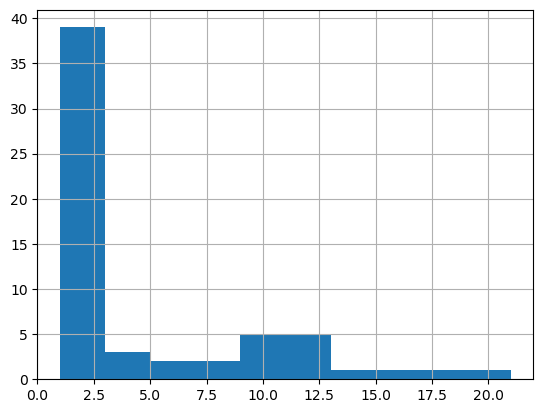

In [20]:
df_params.t_ini.hist()

In [21]:
df_params.to_csv(f'data/parameters_{challenge}.csv.gz', index=False)

AttributeError: 'DataFrame' object has no attribute 'adm_1'

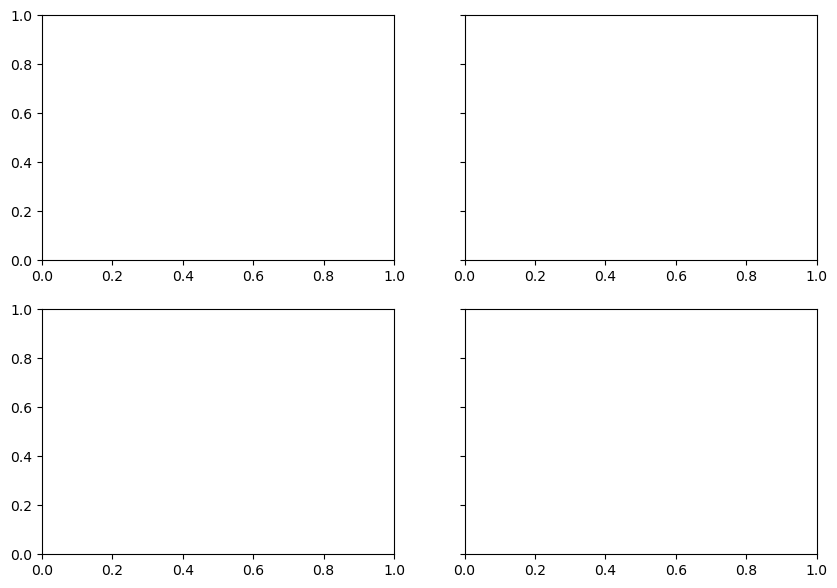

In [16]:

_, ax = plt.subplots(2,2, figsize = (10,7), sharey=True)

state = 22
validation = 1

for ax_, validation in zip(ax.ravel(), [1,2,3,4]): 
    df_state = df_.loc[(df_.adm_1 == state) & (df_.validation == validation)].sort_values(by = 'date')

    r0_i, pico_i, t_ini_i, max_c_i, richfun_opt  = otim_single_path(df_state.casos.values)


    ax_.plot(df_state.date, df_state.casos, color = 'black')
    ax_.plot(df_state.date, diff_r)
    ax_.set_title(f'Validation: {validation}')
    ax_.axvline(df_state['date'].values[int(t_ini_i)], color = 'red')

ax_.plot(df_state.date, diff_r, color = 'tab:blue', label = 'Model')
ax_.axvline(df_state['date'].values[int(t_ini_i)], color = 'red', label = 'Semana de início')
ax_.legend()

plt.suptitle('PI', y = 0.95, fontsize =14)
plt.tight_layout()

plt.show()

In [ ]:
df_state['date'].values

array(['2022-10-09T00:00:00.000000', '2022-10-16T00:00:00.000000',
       '2022-10-23T00:00:00.000000', '2022-10-30T00:00:00.000000',
       '2022-11-06T00:00:00.000000', '2022-11-13T00:00:00.000000',
       '2022-11-20T00:00:00.000000', '2022-11-27T00:00:00.000000',
       '2022-12-04T00:00:00.000000', '2022-12-11T00:00:00.000000',
       '2022-12-18T00:00:00.000000', '2022-12-25T00:00:00.000000',
       '2023-01-01T00:00:00.000000', '2023-01-08T00:00:00.000000',
       '2023-01-15T00:00:00.000000', '2023-01-22T00:00:00.000000',
       '2023-01-29T00:00:00.000000', '2023-02-05T00:00:00.000000',
       '2023-02-12T00:00:00.000000', '2023-02-19T00:00:00.000000',
       '2023-02-26T00:00:00.000000', '2023-03-05T00:00:00.000000',
       '2023-03-12T00:00:00.000000', '2023-03-19T00:00:00.000000',
       '2023-03-26T00:00:00.000000', '2023-04-02T00:00:00.000000',
       '2023-04-09T00:00:00.000000', '2023-04-16T00:00:00.000000',
       '2023-04-23T00:00:00.000000', '2023-04-30T00:00:00.0000

In [ ]:
df_state['date'].values[int(t_ini_i)]

np.datetime64('2022-11-20T00:00:00.000000')

In [ ]:
df_state

,date,adm_1,casos,validation
8,2022-10-09,22,19,1
35,2022-10-16,22,17,1
62,2022-10-23,22,13,1
89,2022-10-30,22,15,1
116,2022-11-06,22,21,1
143,2022-11-13,22,24,1
170,2022-11-20,22,28,1
197,2022-11-27,22,11,1
224,2022-12-04,22,4,1
251,2022-12-11,22,1,1
